In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv(r"C:\Users\reddy\Downloads\archive (2)\customer_churn_with_missing_values.csv")
df.head()
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,age
0,ID0000,Male,1,Yes,Yes,62,Yes,No,No,No,...,No internet service,No internet service,No,Two year,Yes,Electronic check,24.12,2879.77,Yes,72.0
1,ID0001,Female,1,Yes,Yes,11,No,No,Fiber optic,No,...,Yes,No,No,Month-to-month,No,Credit card (automatic),64.17,5618.99,Yes,48.0
2,ID0002,Female,1,No,No,10,Yes,Yes,No,No,...,No internet service,No internet service,No internet service,Month-to-month,Yes,Bank transfer (automatic),75.12,2417.24,Yes,47.0
3,ID0003,Female,0,Yes,Yes,12,Yes,Yes,No,No,...,No,No,Yes,Month-to-month,No,Bank transfer (automatic),86.51,258.47,Yes,83.0
4,ID0004,Male,0,Yes,Yes,34,Yes,No phone service,Fiber optic,Yes,...,No internet service,No internet service,Yes,Month-to-month,Yes,Electronic check,49.12,366.14,Yes,88.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,ID7038,Female,1,No,No,25,No,No phone service,DSL,No,...,No,No,No internet service,Two year,No,Bank transfer (automatic),89.45,2624.73,No,83.0
7039,ID7039,Female,0,No,Yes,42,No,No phone service,DSL,No,...,No internet service,No internet service,No,One year,No,Mailed check,83.03,81.89,Yes,21.0
7040,ID7040,Female,1,No,Yes,43,No,No phone service,No,Yes,...,No,No internet service,Yes,One year,No,Mailed check,80.54,1100.52,Yes,53.0
7041,ID7041,Male,1,No,Yes,37,Yes,Yes,DSL,No internet service,...,No,No,No,Month-to-month,Yes,Credit card (automatic),36.71,2866.15,Yes,74.0


In [4]:
df['Churn'].value_counts()

Churn
Yes    3547
No     3496
Name: count, dtype: int64

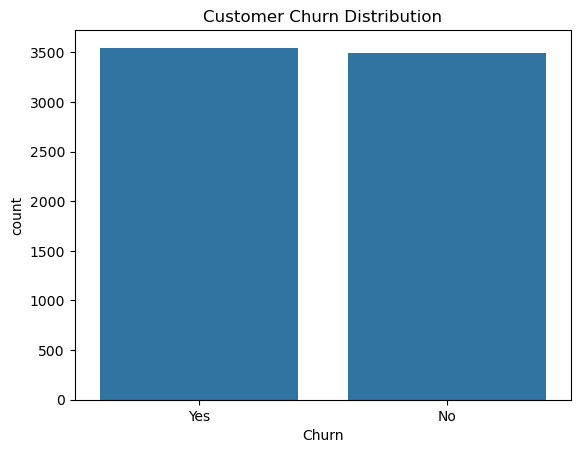

In [5]:
#Visualization
sns.countplot(x='Churn', data=df)
plt.title("Customer Churn Distribution")
plt.show()

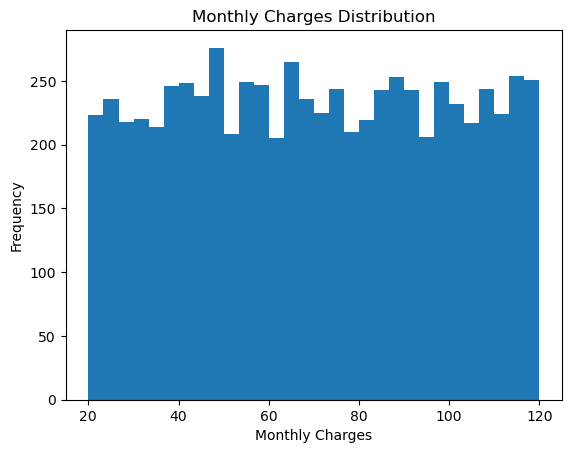

In [11]:
#Histogram (Numerical)
plt.hist(df['MonthlyCharges'], bins=30)
plt.title("Monthly Charges Distribution")
plt.xlabel("Monthly Charges")
plt.ylabel("Frequency")
plt.show()

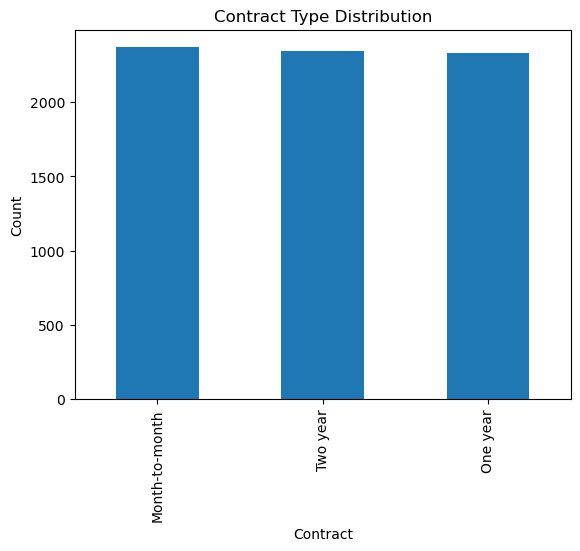

In [7]:
#Bar Chart (Categorical)
df['Contract'].value_counts().plot(kind='bar')
plt.title("Contract Type Distribution")
plt.xlabel("Contract")
plt.ylabel("Count")
plt.show()

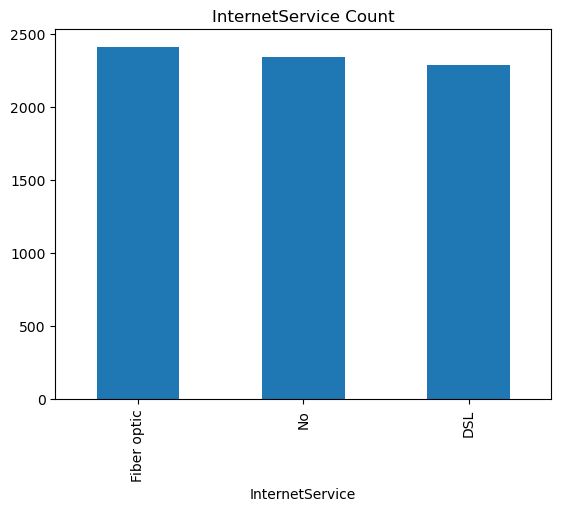

In [13]:
#Bar Chart (Categorical)
df['InternetService'].value_counts().plot(kind='bar')
plt.title("InternetService Count")
plt.show()

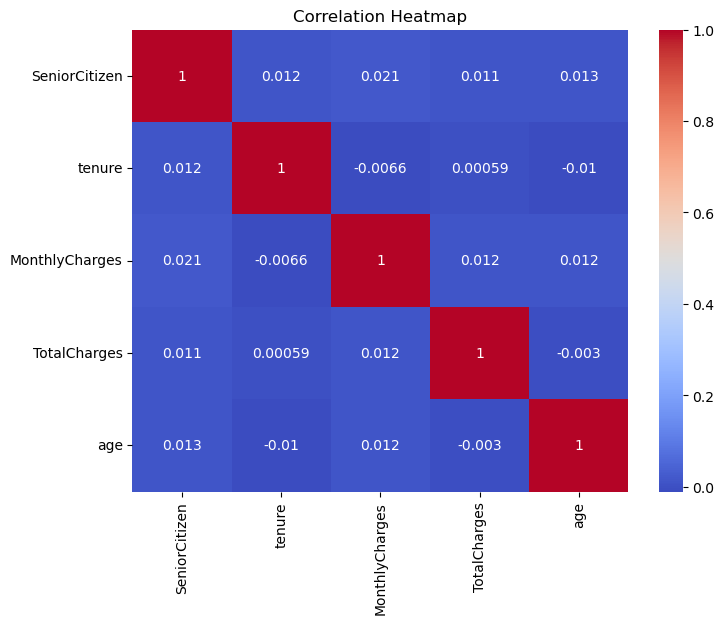

In [8]:
#Multivariate Analysis & Correlation
#Correlation Matrix
#Heatmap
corr = df.corr(numeric_only=True)
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

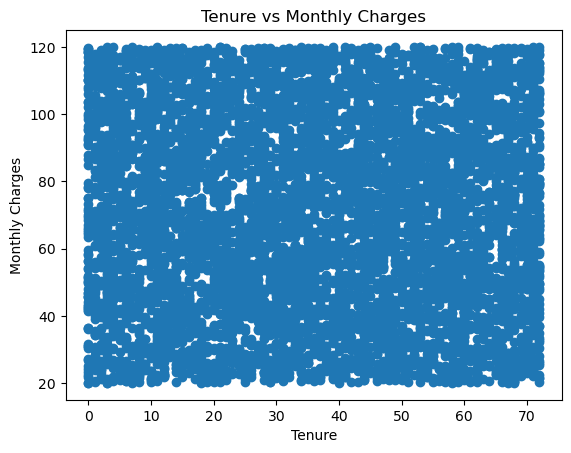

In [9]:
#Scatter Plot
plt.scatter(df['tenure'], df['MonthlyCharges'])
plt.xlabel("Tenure")
plt.ylabel("Monthly Charges")
plt.title("Tenure vs Monthly Charges")
plt.show()

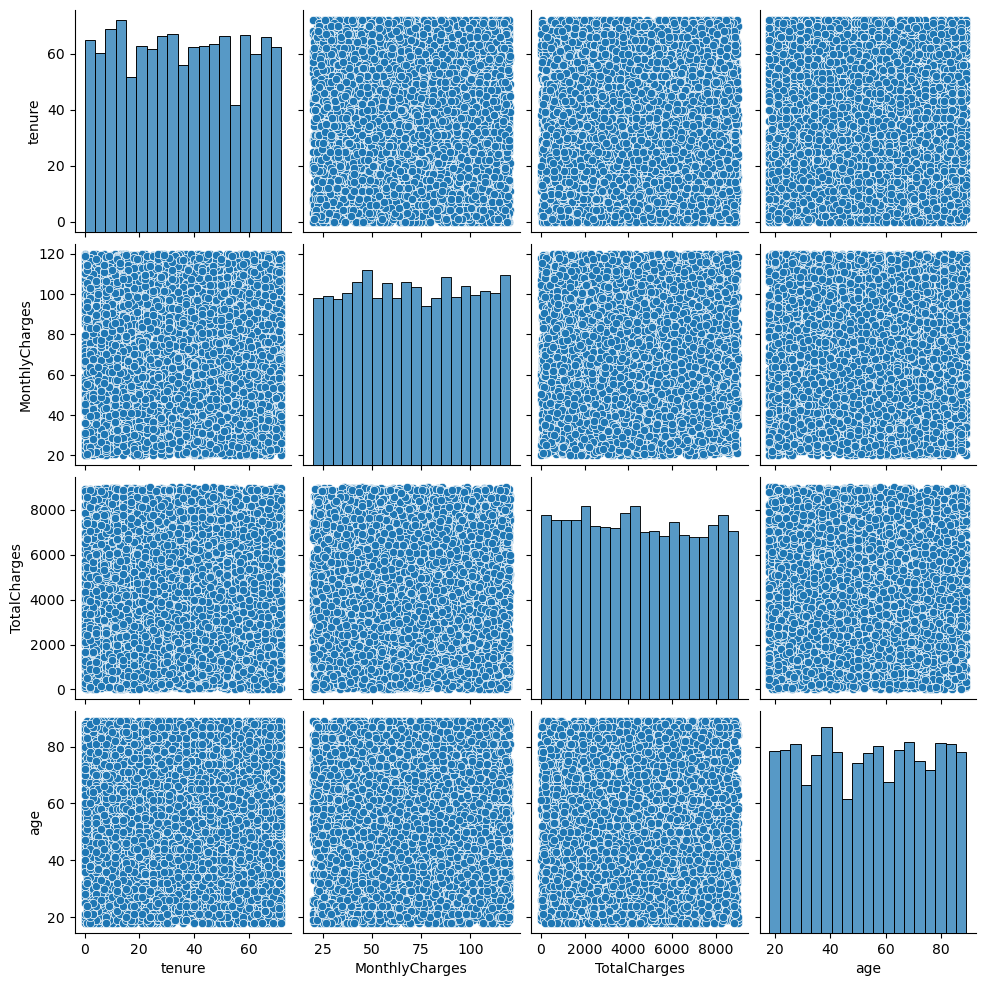

In [10]:
#Pair Plot
sns.pairplot(df[['tenure','MonthlyCharges','TotalCharges','age']])
plt.show()

In [2]:
import pandas as pd
import sqlite3

# Load dataset
df = pd.read_csv(r"C:\Users\reddy\Downloads\archive (2)\customer_churn_with_missing_values.csv")

# Create database connection
conn = sqlite3.connect("churn.db")

# Store table
df.to_sql("customer_churn", conn, if_exists="replace", index=False)

7043

In [3]:
query = """
SELECT Churn, COUNT(*) AS total_customers
FROM customer_churn
GROUP BY Churn;
"""

result = pd.read_sql(query, conn)

print(result)

  Churn  total_customers
0    No             3496
1   Yes             3547


In [4]:
query = """
SELECT Contract,
       AVG(MonthlyCharges) AS avg_monthly_charges
FROM customer_churn
GROUP BY Contract;
"""

result = pd.read_sql(query, conn)
print(result)

         Contract  avg_monthly_charges
0  Month-to-month            70.260865
1        One year            70.660339
2        Two year            69.854996


In [5]:
query = """
SELECT InternetService,
       COUNT(*) AS total_customers,
       SUM(CASE WHEN Churn='Yes' THEN 1 ELSE 0 END) AS churned_customers
FROM customer_churn
GROUP BY InternetService;
"""

result = pd.read_sql(query, conn)
print(result)

  InternetService  total_customers  churned_customers
0             DSL             2287               1135
1     Fiber optic             2411               1218
2              No             2345               1194


In [6]:
query = """
SELECT PaymentMethod,
       COUNT(*) AS total_users
FROM customer_churn
GROUP BY PaymentMethod
ORDER BY total_users DESC;
"""

result = pd.read_sql(query, conn)
print(result)

               PaymentMethod  total_users
0           Electronic check         1828
1               Mailed check         1803
2  Bank transfer (automatic)         1722
3    Credit card (automatic)         1690


In [7]:
query = """
SELECT AVG(tenure) AS avg_tenure_churned
FROM customer_churn
WHERE Churn = 'Yes';
"""

result = pd.read_sql(query, conn)
print(result)

   avg_tenure_churned
0           36.123485


In [8]:
query = """
SELECT AVG(tenure) AS avg_tenure_churned
FROM customer_churn
WHERE Churn = 'Yes';
"""

result = pd.read_sql(query, conn)
print(result)

   avg_tenure_churned
0           36.123485


In [9]:
query = """
SELECT Churn,
       AVG(MonthlyCharges) AS avg_monthly_charges
FROM customer_churn
GROUP BY Churn;
"""

result = pd.read_sql(query, conn)
print(result)

  Churn  avg_monthly_charges
0    No            70.089385
1   Yes            70.423964


In [10]:
query = """
SELECT Churn,
       AVG(age) AS avg_age
FROM customer_churn
GROUP BY Churn;
"""

result = pd.read_sql(query, conn)
print(result)

  Churn    avg_age
0    No  53.948549
1   Yes  53.333824
